In [162]:
import retinanalysis as ra
import numpy as np
import importlib
importlib.reload(ra.mea_pipeline)
importlib.reload(ra.sta)
import os
import gc

In [163]:
str_stas = '/home/vyomr/Desktop/data/analysis/20260415C/chunk3/kilosort2.5/kilosort2.5_matmul_stas.npy' 
stas = np.load(str_stas)
sta_cell_ids = np.array([  1,   2,   3,   5,   6,   8,   9,  10,  11,  12,  13,  14,  15,
        16,  17,  19,  20,  21,  22,  23,  24,  25,  26,  27,  28,  29,
        30,  32,  33,  34,  35,  36,  37,  38,  39,  40,  41,  42,  45,
        46,  47,  48,  49,  50,  51,  52,  53,  54,  55,  56,  57,  58,
        60,  61,  62,  63,  64,  66,  67,  68,  69,  70,  71,  72,  73,
        74,  75,  76,  78,  79,  80,  82,  83,  84,  85,  86,  87,  88,
        89,  90,  91,  92,  93,  94,  95,  96,  97,  98,  99, 100, 101,
       102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114,
       128, 130, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142,
       143, 144, 145, 146, 147, 148, 149, 151, 152, 153, 154, 155, 156,
       157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168, 169,
       170, 115, 116, 117, 118, 119, 120, 121, 122, 123, 125, 126, 127,
       171, 172, 173, 174, 175, 176, 177, 179, 180, 182, 184, 185, 186,
       187, 188, 189, 190, 191, 192, 193, 194, 195, 197, 198, 199, 201,
       202, 203, 204, 205, 208, 209, 210, 211, 212, 213, 214, 215, 216,
       217, 218, 219, 220, 222, 223, 224, 225, 226, 227, 230, 231, 232,
       256, 257, 258, 259, 260, 261, 262, 263, 264, 265, 266, 267, 268,
       269, 270, 271, 272, 273, 274, 275, 276, 277, 278, 279, 281, 282,
       283, 284, 285, 286, 287, 288, 233, 234, 235, 236, 238, 239, 240,
       241, 242, 243, 244, 245, 246, 247, 248, 250, 252, 253, 254, 255,
       289, 290, 291, 292, 294, 295, 296, 297, 300, 301, 302, 303, 305,
       306, 308, 310, 312, 313, 314, 315, 316, 317, 318, 319, 320, 321,
       322, 323, 324, 325, 326, 327, 328, 329, 330, 332, 333, 334, 335,
       336, 337, 338, 339, 340, 341, 344, 346, 347, 348, 349, 350, 351,
       384, 385, 386, 387, 389, 390, 391, 393, 394, 395, 397, 398, 399,
       400, 401, 402, 403, 404, 405, 406, 407, 408, 409, 410, 411, 412,
       413, 414, 352, 353, 355, 356, 357, 359, 360, 361, 365, 366, 368,
       370, 371, 372, 373, 374, 375, 376, 377, 378, 379, 380, 382, 383,
       415, 416, 418, 419, 420, 423, 424, 426, 427, 429, 430, 431, 432,
       433, 434, 435, 436, 438, 440, 442, 443, 444, 447, 448, 450, 451,
       452, 453, 455, 456, 457, 458, 459, 460, 461, 465, 466, 467, 468,
       469, 470, 473, 474, 475, 476, 477, 478, 479, 480, 481, 482, 484,
       486, 488, 489])

In [164]:
# Sort in ascending order of cell IDs
stas = stas[np.argsort(sta_cell_ids)]

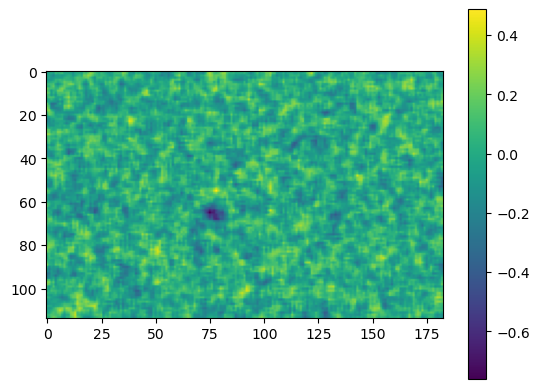

In [165]:
import matplotlib.pyplot as plt
plt.imshow(stas[102, -4, :, :, 0])
plt.colorbar()

## Load NAS STA for comparison

In [166]:
importlib.reload(ra.utils.vision_utils)
exp_name = '20260415C'
chunk_name = 'chunk3'
vcd = ra.utils.vision_utils.get_analysis_vcd(exp_name, chunk_name, 'kilosort2.5', include_sta=True)

Loading VCD from /mnt/Volumes/data-1/analysis/20260415C/chunk3/kilosort2.5 ...
VCD loaded with 419 cells.



In [167]:
def get_all_vcd_stas(vcd):
    cell_ids = vcd.get_cell_ids()
    stas = []
    for cell_id in cell_ids:
        # [H, W, D] for each channel
        vcd_sta = vcd.get_sta_for_cell(cell_id)
        vcd_sta = [vcd_sta.red, vcd_sta.green, vcd_sta.blue]
        # Make [D, H, W, C]
        vcd_sta = np.stack(vcd_sta, axis=-1).transpose(2, 0, 1, 3)
        stas.append(vcd_sta)
    return np.stack(stas, axis=0)
vcd_stas = get_all_vcd_stas(vcd)

(array([27., 48., 50., 34., 49., 38., 41., 27., 13., 10.,  9., 10.,  9.,
        10., 15.,  8.,  8.,  5.,  5.,  3.]),
 array([0.47623611, 0.49802769, 0.51981927, 0.54161086, 0.56340244,
        0.58519402, 0.6069856 , 0.62877718, 0.65056876, 0.67236034,
        0.69415192, 0.7159435 , 0.73773509, 0.75952667, 0.78131825,
        0.80310983, 0.82490141, 0.84669299, 0.86848457, 0.89027615,
        0.91206773]),
 <BarContainer object of 20 artists>)

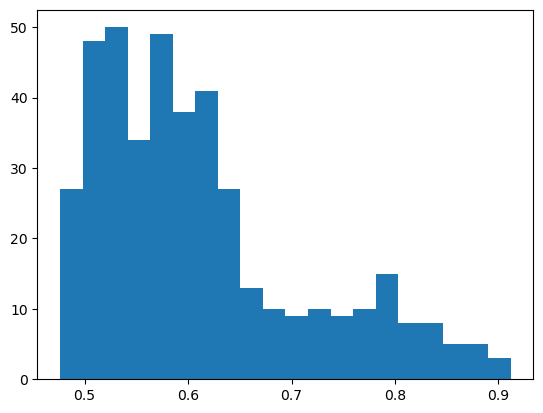

In [168]:
corrs = []
for i in range(stas.shape[0]):
    ra_sta = stas[i]
    vcd_sta = vcd_stas[i]
    # vcd sta is cropped, so crop ra_sta
    crop_h = vcd_sta.shape[1]
    crop_w = vcd_sta.shape[2]
    h_start = (ra_sta.shape[1] - crop_h) // 2
    w_start = (ra_sta.shape[2] - crop_w) // 2
    ra_sta = ra_sta[:, h_start:h_start+crop_h, w_start:w_start+crop_w, :]
    corr = np.corrcoef(ra_sta.flatten(), vcd_sta.flatten())[0, 1]
    corrs.append(corr)

plt.hist(corrs, bins=20)

Text(0, 0.5, 'Correlation between RA STA and VCD STA')

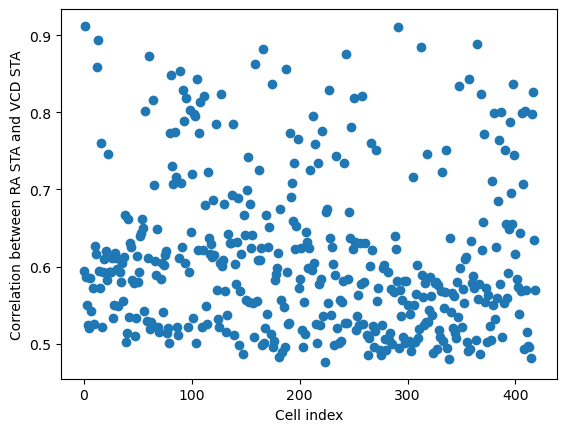

In [169]:
plt.plot(corrs, 'o')
plt.xlabel('Cell index')
plt.ylabel('Correlation between RA STA and VCD STA')

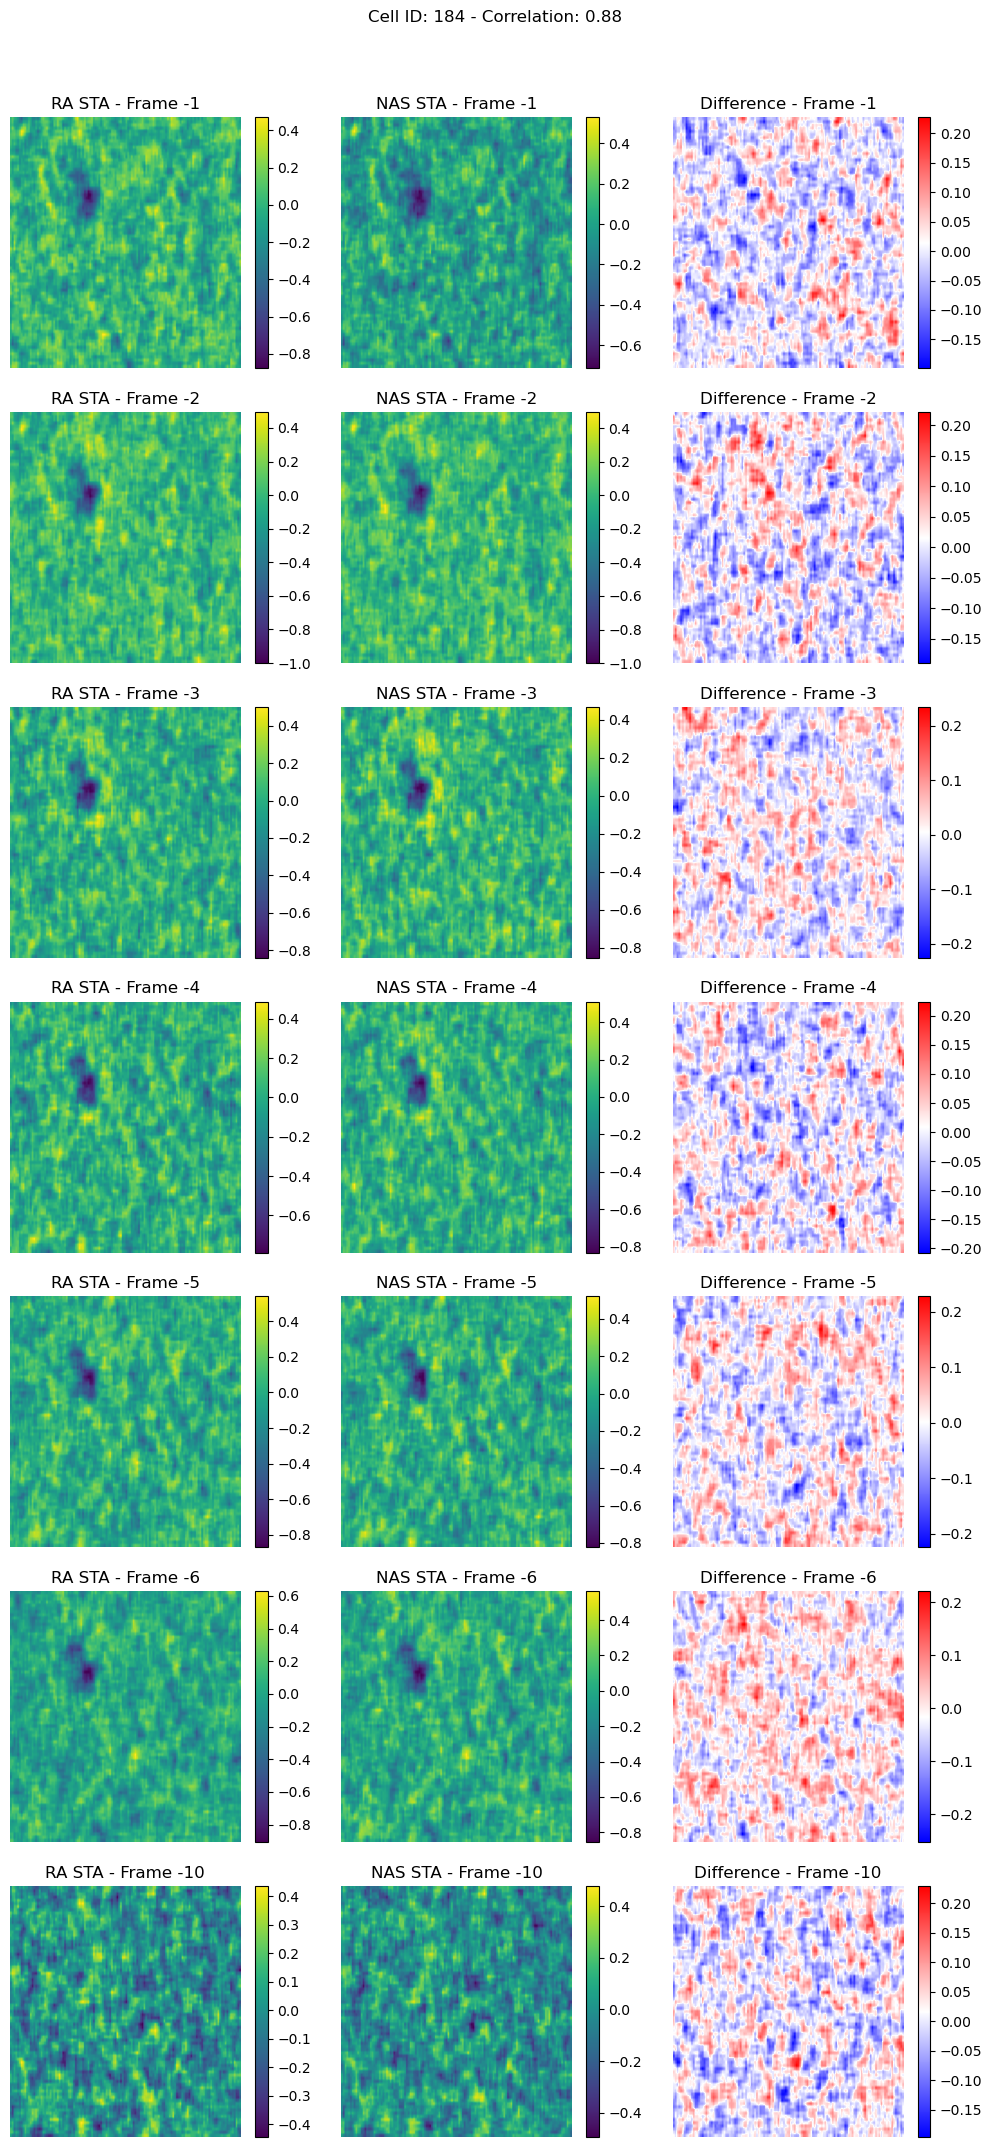

In [193]:
def compare_sta_to_vcd(stas, vcd_stas, cell_idx=100):
    cell_ids = vcd.get_cell_ids()
    cell_id = cell_ids[cell_idx]

    ra_sta = stas[cell_idx]

    vcd_sta = vcd_stas[cell_idx]

    # ra_sta = ra_sta[1:]
    # vcd_sta = vcd_sta[:-1]

    # vcd sta is cropped, so crop ra_sta
    crop_h = vcd_sta.shape[1]
    crop_w = vcd_sta.shape[2]
    h_start = (ra_sta.shape[1] - crop_h) // 2
    w_start = (ra_sta.shape[2] - crop_w) // 2
    ra_sta = ra_sta[:, h_start:h_start+crop_h, w_start:w_start+crop_w, :]

    # Frame to plot
    ls_frames = [-1, -2, -3, -4, -5, -6, -10]
    fig, axs = plt.subplots(nrows=len(ls_frames), ncols=3, figsize=(10, 3*len(ls_frames)))
    i_channel = 0
    for i, i_frame in enumerate(ls_frames):
        im=axs[i, 0].imshow(ra_sta[i_frame, :, :, i_channel], aspect='auto')
        plt.colorbar(im, ax=axs[i, 0])
        axs[i, 0].set_title(f'RA STA - Frame {i_frame}')
        im=axs[i, 1].imshow(vcd_sta[i_frame, :, :, i_channel], aspect='auto')
        plt.colorbar(im, ax=axs[i, 1])
        axs[i, 1].set_title(f'NAS STA - Frame {i_frame}')
        diff = ra_sta[i_frame, :, :, i_channel] - vcd_sta[i_frame, :, :, i_channel]
        im=axs[i, 2].imshow(diff, aspect='auto', cmap='bwr')
        plt.colorbar(im, ax=axs[i, 2])
        axs[i, 2].set_title(f'Difference - Frame {i_frame}')
        
    r = np.corrcoef(ra_sta.flatten(), vcd_sta.flatten())[0, 1]
    plt.suptitle(f'Cell ID: {cell_id} - Correlation: {r:.2f}', y=1.02)
    for ax in axs.flatten():
        ax.axis('off')
    plt.tight_layout()
    # plt.show()

compare_sta_to_vcd(stas, vcd_stas, cell_idx=np.argsort(corrs)[-6])
# compare_sta_to_vcd(stas, vcd_stas, cell_idx=313)
# compare_sta_to_vcd(stas, vcd_stas, cell_idx=104)

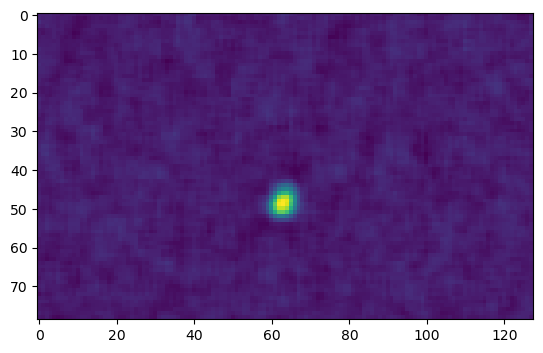

In [109]:
plt.imshow(ra_sta[-1,:,:,0])

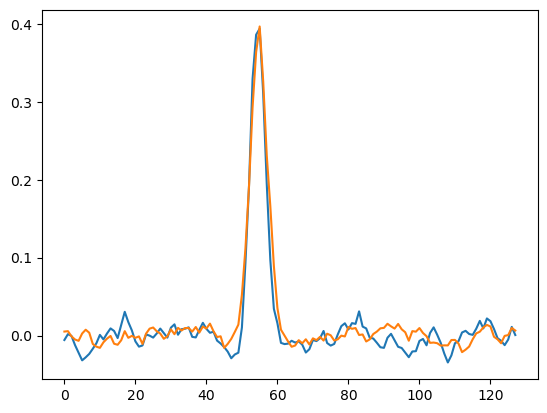

In [130]:
cell_idx = 81
ra_sta = stas[cell_idx]

vcd_sta = vcd_stas[cell_idx]


# vcd sta is cropped, so crop ra_sta
crop_h = vcd_sta.shape[1]
crop_w = vcd_sta.shape[2]
h_start = (ra_sta.shape[1] - crop_h) // 2-2
w_start = (ra_sta.shape[2] - crop_w) // 2 +9 
ra_sta = ra_sta[:, h_start:h_start+crop_h, w_start:w_start+crop_w, :]

plt.plot(ra_sta[-1, 48, :, 0])
plt.plot(vcd_sta[-1, 48, :, 0])